# OPERA DISP-S1 Land Subsidence Analysis
## Following Official OPERA GitHub Methodology

This notebook follows the exact methodology from:
https://github.com/OPERA-Cal-Val/OPERA_Applications/blob/main/DISP/Subsidence/DISP-S1_Land_Subsidence.ipynb

**Required Environment**: `conda activate opera_env` (Python 3.12+)

**Steps**:
1. Install OPERA utilities and dependencies
2. Set up NASA Earthdata authentication
3. Download DISP-S1 data using `opera-utils`
4. Load and analyze ministack structure
5. Visualize displacement time series

**Data**: OPERA L3 DISP-S1 - Surface Displacement from Sentinel-1 InSAR

## 1. Install Dependencies

Install required packages following the GitHub notebook.
This includes opera_utils, disp-xr, and MintPy from their repositories.

In [ ]:
import sys
import subprocess

def install_dependencies():
    """Install OPERA utilities and required packages"""
    
    # Check Python version
    import sys
    py_version = sys.version_info
    print(f"Python version: {py_version.major}.{py_version.minor}.{py_version.micro}")
    
    if py_version < (3, 12):
        print("❌ ERROR: disp-xr requires Python >= 3.12")
        print("   Please activate opera_env: conda activate opera_env")
        return
    
    # Install opera_utils from GitHub
    print("Installing opera_utils...")
    subprocess.run([sys.executable, "-m", "pip", "install", 
                   "git+https://github.com/opera-adt/opera-utils.git", "-q"])
    
    # Clone and install disp-xr
    print("Installing disp-xr...")
    subprocess.run(["git", "clone", "https://github.com/opera-adt/disp-xr.git"], 
                  capture_output=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", "./disp-xr", "-q"])
    
    # Install geospatial and scientific packages
    print("Installing geospatial packages...")
    geo_packages = [
        "matplotlib", "pandas", "numpy", "scipy",
        "rasterio", "rioxarray", "geopandas", "shapely", "pyproj",
        "h5netcdf", "h5py", "netcdf4", "xarray",
        "cartopy", "folium", "contextily", "asf_search"
    ]
    subprocess.run([sys.executable, "-m", "pip", "install"] + geo_packages + ["-q"])
    
    # Install MintPy
    print("Installing MintPy...")
    subprocess.run([sys.executable, "-m", "pip", "install", 
                   "git+https://github.com/insarlab/MintPy.git", "-q"])
    
    # Install Jupyter packages
    print("Installing Jupyter packages...")
    subprocess.run([sys.executable, "-m", "pip", "install", 
                   "ipykernel", "ipywidgets", "-q"])
    
    # Add to path
    sys.path.insert(0, "disp-xr/src")
    
    print("✅ All dependencies installed successfully!")

install_dependencies()

Python version: 3.12.12
Installing opera_utils...
Installing disp-xr...
Installing geospatial packages...
Installing MintPy...
Installing Jupyter packages...
✅ All dependencies installed successfully!


## 2. Import Libraries

In [7]:
import os
import glob
from pathlib import Path
from netrc import netrc, NetrcParseError
from getpass import getpass

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import rasterio
import geopandas as gpd
from shapely.geometry import box

# Import OPERA custom tools
from disp_xr import product, stack as disp_stack, quality_metrics

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 3. Setup NASA Earthdata Authentication

OPERA DISP-S1 data requires NASA Earthdata credentials.
This cell creates a .netrc file if it doesn't exist.

In [8]:
# Setup Earthdata credentials
urs = 'urs.earthdata.nasa.gov'
netrc_name = ".netrc"
netrc_path = os.path.expanduser(f"~/{netrc_name}")

def write_netrc():
    """Prompt for and write Earthdata credentials"""
    username = getpass(prompt='Enter NASA Earthdata Login Username: ')
    password = getpass(prompt='Enter NASA Earthdata Login Password: ')
    
    with open(netrc_path, 'a') as f:
        f.write(f"\nmachine {urs}\n")
        f.write(f"login {username}\n")
        f.write(f"password {password}\n")
    
    os.chmod(netrc_path, 0o600)
    print("✅ Credentials saved to ~/.netrc")

def has_urs_credentials():
    """Check if .netrc has Earthdata credentials"""
    try:
        creds = netrc(netrc_path).authenticators(urs)
        return creds is not None
    except (FileNotFoundError, NetrcParseError):
        return False

if not has_urs_credentials():
    print("⚠️  No NASA Earthdata credentials found.")
    if not os.path.exists(netrc_path):
        open(netrc_path, 'w').close()
    write_netrc()
else:
    print("✅ NASA Earthdata credentials found in ~/.netrc")

✅ NASA Earthdata credentials found in ~/.netrc


## 4. Define Area of Interest and Parameters

**San Simon / Bowie Subsidence Area in Arizona** (from GitHub example)
- Known subsidence area from groundwater extraction
- BBOX format: "min_lon min_lat max_lon max_lat"

In [9]:
# AOI Parameters (San Simon/Bowie, Arizona - from GitHub example)
BBOX = "-109.557301 32.153525 -109.03012 32.456474"
FRAME_ID = "34478"  # Frame covering this area

# Date range
start_date = '2022-01-01'
end_date = '2024-09-15'

# Processing parameters
N_WORKERS = 4
OUTPUT_DIR = Path('/mnt/data/opera_disp_s1')

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"AOI Bounding Box: {BBOX}")
print(f"Frame ID: {FRAME_ID}")
print(f"Date Range: {start_date} to {end_date}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Workers: {N_WORKERS}")

AOI Bounding Box: -109.557301 32.153525 -109.03012 32.456474
Frame ID: 34478
Date Range: 2022-01-01 to 2024-09-15
Output Directory: /mnt/data/opera_disp_s1
Workers: 4


## 5. Download DISP-S1 Data using opera-utils

This uses the official `opera-utils disp-s1-download` command-line tool.
The data will be cropped to the bounding box and saved to the output directory.

## 4b. Check Available Products (Before Download)

Query NASA CMR to see what products are available for your AOI and estimate download size.

Querying NASA CMR for available products...

✅ Found 322 OPERA DISP-S1 granules

📦 Frame 34478 Summary:
  Products: 82
  Total size: 29.88 GB
  Average file size: 373.15 MB

🗂️  Ministack Structure:
  Unique ministacks: 6
  Products per ministack:
    20210919: 7 acquisitions
    20220411: 15 acquisitions
    20221008: 15 acquisitions
    20230406: 15 acquisitions
    20231003: 15 acquisitions
    ... and 1 more ministacks

📅 Temporal Coverage:
  First acquisition: 20220105
  Last acquisition: 20240927


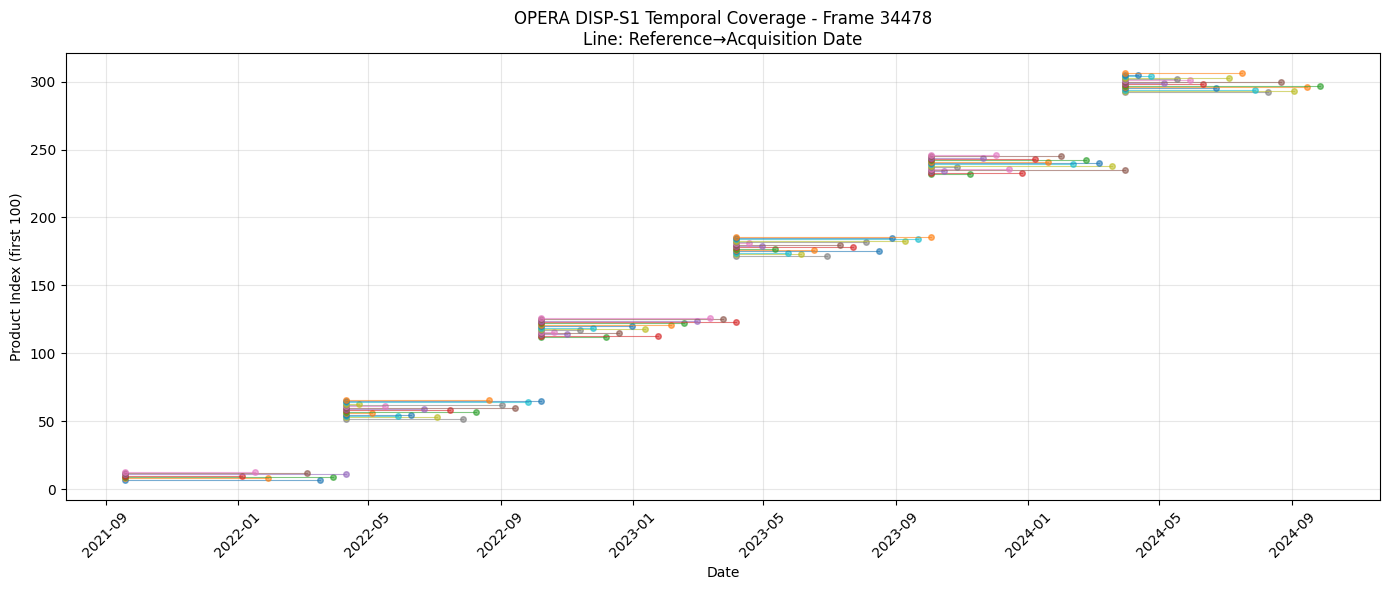


✅ Pre-download check complete!
   Ready to download to: /mnt/data/opera_disp_s1


In [12]:
# Query CMR to check available products
import requests
import re

# Search CMR for OPERA DISP-S1 products
cmr_url = "https://cmr.earthdata.nasa.gov/search/granules.json"

# Convert BBOX string to tuple
bbox_parts = BBOX.split()
bbox_tuple = (float(bbox_parts[0]), float(bbox_parts[1]), float(bbox_parts[2]), float(bbox_parts[3]))

params = {
    'short_name': 'OPERA_L3_DISP-S1_V1',
    'bounding_box': ','.join(map(str, bbox_tuple)),
    'temporal': f'{start_date}T00:00:00Z,{end_date}T23:59:59Z',
    'page_size': 2000
}

print("Querying NASA CMR for available products...")
response = requests.get(cmr_url, params=params)
results = response.json()

if 'feed' in results and 'entry' in results['feed']:
    granules = results['feed']['entry']
    print(f"\n✅ Found {len(granules)} OPERA DISP-S1 granules")
    
    # Parse granule information
    granule_info = []
    total_size_mb = 0
    
    for granule in granules:
        granule_id = granule.get('title', '')
        
        # Extract frame ID
        frame_match = re.search(r'_F(\d+)_', granule_id)
        frame = frame_match.group(1) if frame_match else 'Unknown'
        
        # Extract dates
        date_matches = re.findall(r'(\d{8})T\d{6}Z', granule_id)
        
        # Get file size
        size_mb = 0
        if 'granule_size' in granule:
            size_mb = float(granule['granule_size'])
        
        total_size_mb += size_mb
        
        granule_info.append({
            'granule_id': granule_id,
            'frame': frame,
            'ref_date': date_matches[0] if len(date_matches) > 0 else None,
            'acq_date': date_matches[1] if len(date_matches) > 1 else None,
            'size_mb': size_mb
        })
    
    df_granules = pd.DataFrame(granule_info)
    
    # Filter to specified frame
    if FRAME_ID:
        df_frame = df_granules[df_granules['frame'] == FRAME_ID]
        frame_size_gb = df_frame['size_mb'].sum() / 1024
        
        print(f"\n📦 Frame {FRAME_ID} Summary:")
        print(f"  Products: {len(df_frame)}")
        print(f"  Total size: {frame_size_gb:.2f} GB")
        print(f"  Average file size: {df_frame['size_mb'].mean():.2f} MB")
        
        # Ministack analysis
        if 'ref_date' in df_frame.columns:
            ministacks = df_frame['ref_date'].value_counts().sort_index()
            print(f"\n🗂️  Ministack Structure:")
            print(f"  Unique ministacks: {len(ministacks)}")
            print(f"  Products per ministack:")
            for ref_date, count in ministacks.head(5).items():
                print(f"    {ref_date}: {count} acquisitions")
            if len(ministacks) > 5:
                print(f"    ... and {len(ministacks)-5} more ministacks")
        
        # Date range
        if 'acq_date' in df_frame.columns and len(df_frame) > 0:
            print(f"\n📅 Temporal Coverage:")
            print(f"  First acquisition: {df_frame['acq_date'].min()}")
            print(f"  Last acquisition: {df_frame['acq_date'].max()}")
            
            # Visualize temporal coverage
            fig, ax = plt.subplots(figsize=(14, 6))
            
            # Convert dates to datetime for plotting
            df_plot = df_frame.copy()
            # Extract just the date part (YYYYMMDD) before the 'T' if it exists
            df_plot['ref_date_clean'] = df_plot['ref_date'].str[:8]
            df_plot['acq_date_clean'] = df_plot['acq_date'].str[:8]
            df_plot['ref_datetime'] = pd.to_datetime(df_plot['ref_date_clean'], format='%Y%m%d')
            df_plot['acq_datetime'] = pd.to_datetime(df_plot['acq_date_clean'], format='%Y%m%d')
            
            # Plot each acquisition as a line from ref to acq date
            for idx, row in df_plot.head(100).iterrows():  # Limit to first 100 for visibility
                ax.plot([row['ref_datetime'], row['acq_datetime']], [idx, idx], 
                       'o-', markersize=4, linewidth=0.8, alpha=0.6)
            
            ax.set_xlabel('Date')
            ax.set_ylabel('Product Index (first 100)')
            ax.set_title(f'OPERA DISP-S1 Temporal Coverage - Frame {FRAME_ID}\nLine: Reference→Acquisition Date')
            ax.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
    else:
        print(f"\n💾 Total Download Volume:")
        print(f"  Total size: {total_size_mb/1024:.2f} GB")
        print(f"\nFrames available:")
        frame_counts = df_granules['frame'].value_counts()
        for frame, count in frame_counts.head(10).items():
            print(f"  Frame {frame}: {count} products")
    
    print(f"\n✅ Pre-download check complete!")
    print(f"   Ready to download to: {OUTPUT_DIR}")
    
else:
    print("⚠️  No products found or error querying CMR")

In [18]:
# Set environment variables for the command
os.environ['BBOX'] = BBOX
os.environ['FRAME_ID'] = FRAME_ID
os.environ['START'] = start_date
os.environ['END'] = end_date
os.environ['NUM_WORKERS'] = str(N_WORKERS)
os.environ['OUTPUT_DIR'] = str(OUTPUT_DIR)  # Add this for bash access

print("Starting OPERA DISP-S1 download...")
print("This may take several minutes depending on the number of files...")
print()

Starting OPERA DISP-S1 download...
This may take several minutes depending on the number of files...



In [ ]:
# Download DISP-S1 data using ASF API
# Note: opera-utils disp-s1-download command doesn't exist in current version
# Using asf_search Python library instead

import asf_search as asf
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

# Parse BBOX
bbox_parts = BBOX.split()
bbox_tuple = [float(x) for x in bbox_parts]  # [west, south, east, north]

print(f"Searching for DISP-S1 products...")
print(f"  BBOX: {bbox_tuple}")
print(f"  Frame: {FRAME_ID}")
print(f"  Date range: {start_date} to {end_date}")

# Search for OPERA DISP-S1 products
# Use dataset parameter instead of platform for OPERA products
results = asf.search(
    dataset=asf.DATASET.OPERA_S1,
    processingLevel='DISP-S1',
    intersectsWith=f"POLYGON(({bbox_tuple[0]} {bbox_tuple[1]}, {bbox_tuple[2]} {bbox_tuple[1]}, {bbox_tuple[2]} {bbox_tuple[3]}, {bbox_tuple[0]} {bbox_tuple[3]}, {bbox_tuple[0]} {bbox_tuple[1]}))",
    start=start_date,
    end=end_date
)

# Filter by frame ID
frame_results = [r for r in results if f"F{FRAME_ID}" in r.properties.get('fileID', r.properties.get('sceneName', ''))]

print(f"\n✅ Found {len(frame_results)} products for Frame {FRAME_ID}")

# Calculate total size (handle different size formats)
total_size = 0
for r in frame_results:
    size = r.properties.get('bytes', r.properties.get('sizeMB', 0))
    if isinstance(size, (int, float)):
        total_size += size
    elif isinstance(size, dict):
        # Sometimes size is nested in a dict
        total_size += size.get('value', 0)

# Convert to GB (assuming bytes)
if total_size > 1024**3:  # If it looks like bytes
    size_gb = total_size / 1024**3
else:  # Might already be in MB
    size_gb = total_size / 1024

print(f"📦 Total download size: ~{size_gb:.2f} GB")

# Setup authenticated session with explicit credentials from .netrc
print("\n🔐 Setting up authenticated session...")
from netrc import netrc

try:
    # Read credentials from .netrc
    netrc_path = os.path.expanduser("~/.netrc")
    creds = netrc(netrc_path).authenticators('urs.earthdata.nasa.gov')
    
    if creds:
        username, _, password = creds
        print(f"   Found credentials for user: {username}")
        
        # Create authenticated session
        session = asf.ASFSession()
        session.auth_with_creds(username, password)
        print("   ✓ Session authenticated")
    else:
        raise Exception("No credentials found in .netrc for urs.earthdata.nasa.gov")
        
except Exception as e:
    print(f"   ⚠️  Authentication error: {e}")
    print("   Please check your ~/.netrc file")
    raise

# Download function with retry logic
def download_product(result, max_retries=3):
    """Download with retry for transient errors"""
    file_id = result.properties['fileID']
    
    for attempt in range(max_retries):
        try:
            result.download(OUTPUT_DIR, session=session)
            return True, file_id
        except Exception as e:
            error_msg = str(e)
            
            # If rate limited or locked out, don't retry
            if 'exceeded the maximum' in error_msg or '401' in error_msg:
                return False, f"{file_id}: {error_msg}"
            
            # For 500 errors or other transient issues, retry with backoff
            if '500' in error_msg or 'timeout' in error_msg.lower():
                if attempt < max_retries - 1:
                    wait_time = 2 ** attempt  # Exponential backoff: 1s, 2s, 4s
                    time.sleep(wait_time)
                    continue
            
            # Other errors, don't retry
            return False, f"{file_id}: {error_msg}"
    
    return False, f"{file_id}: Failed after {max_retries} retries"

# Download with progress
print(f"\n⬇️  Downloading to {OUTPUT_DIR}...")
print(f"   Using {N_WORKERS} workers")
print(f"   (If you see 401 errors, wait 10 minutes and re-run this cell)")

successful = 0
failed = []

with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    future_to_result = {executor.submit(download_product, r): r for r in frame_results}
    
    for i, future in enumerate(as_completed(future_to_result), 1):
        success, info = future.result()
        if success:
            successful += 1
            print(f"   [{i}/{len(frame_results)}] ✓ {info}")
        else:
            failed.append(info)
            print(f"   [{i}/{len(frame_results)}] ✗ {info}")

print(f"\n{'='*60}")
print(f"✅ Downloaded: {successful}/{len(frame_results)}")
if failed:
    print(f"❌ Failed: {len(failed)}")
    for f in failed[:5]:  # Show first 5 failures
        print(f"   - {f}")
print(f"{'='*60}")

Searching for DISP-S1 products...
  BBOX: [-109.557301, 32.153525, -109.03012, 32.456474]
  Frame: 34478
  Date range: 2022-01-01 to 2024-09-15

✅ Found 82 products for Frame 34478
📦 Total download size: ~0.00 GB

🔐 Setting up authenticated session...

⬇️  Downloading to /mnt/data/opera_disp_s1...
   Using 4 workers
   (If you see 401 errors, wait 10 minutes and re-run this cell)
   [1/82] ✗ OPERA_L3_DISP-S1_IW_F34478_VV_20240331T132028Z_20240927T132027Z_v1.0_20250420T161742Z: HTTP 401: Credentials (username, password) are invalid
   [2/82] ✗ OPERA_L3_DISP-S1_IW_F34478_VV_20240331T132028Z_20240903T132026Z_v1.0_20250420T161742Z: HTTP 401: Credentials (username, password) are invalid
   [3/82] ✗ OPERA_L3_DISP-S1_IW_F34478_VV_20240331T132028Z_20240915T132027Z_v1.0_20250420T161742Z: HTTP 401: Credentials (username, password) are invalid
   [4/82] ✗ OPERA_L3_DISP-S1_IW_F34478_VV_20240331T132028Z_20240822T132026Z_v1.0_20250420T161742Z: HTTP 401: Credentials (username, password) are invalid
 

## 6. Load and Inspect Downloaded Files

Check what files were downloaded and examine the ministack structure.

In [ ]:
# List downloaded files
nc_files = sorted(glob.glob(f"{OUTPUT_DIR}/*.nc"))

print(f"✅ Downloaded {len(nc_files)} NetCDF files")
print("\nFirst few files:")
for f in nc_files[:5]:
    print(f"  {Path(f).name}")

if nc_files:
    print("\n" + "="*60)
    print("Examining first file...")
    print("="*60)
    
    # Open and inspect first file
    ds = xr.open_dataset(nc_files[0], chunks={'time': 1})
    print(ds)
else:
    print("\n⚠️  No files downloaded. Check your parameters and authentication.")

## 7. Visualize Ministack Structure

DISP-S1 uses a "ministack" approach where data is organized into groups with a reference date.
Each ministack can contain up to 15 acquisitions.

In [ ]:
if nc_files:
    # Parse file information
    from disp_xr import product
    
    # Create a dataframe of file information
    file_info = []
    for f in nc_files:
        info = product.parse_filename(Path(f).name)
        info['path'] = f
        file_info.append(info)
    
    df = pd.DataFrame(file_info)
    
    # Display summary
    print("Dataset Summary:")
    print(f"  Total files: {len(df)}")
    print(f"  Date range: {df['date1'].min()} to {df['date2'].max()}")
    print(f"  Unique reference dates: {df['date1'].nunique()}")
    print("\nFirst 10 files:")
    print(df[['date1', 'date2', 'frame']].head(10))
    
    # Plot temporal coverage
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for idx, row in df.iterrows():
        d1 = pd.to_datetime(row['date1'], format='%Y%m%d')
        d2 = pd.to_datetime(row['date2'], format='%Y%m%d')
        ax.plot([d1, d2], [idx, idx], 'o-', markersize=3, linewidth=0.5)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('File Index')
    ax.set_title('OPERA DISP-S1 Temporal Coverage')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Visualize Displacement from Latest File

Display the most recent displacement measurement with quality masking.

In [ ]:
if nc_files:
    # Load last file
    ds = xr.open_dataset(nc_files[-1], chunks={'time': 1})
    
    # Get the last time step
    disp = ds.displacement.isel(time=-1)
    
    # Apply recommended mask
    disp_masked = disp.where(ds.recommended_mask.isel(time=-1) == 1)
    
    # Get date info
    row = df.iloc[-1]
    d1 = pd.to_datetime(row['date1'], format='%Y%m%d').date()
    d2 = pd.to_datetime(row['date2'], format='%Y%m%d').date()
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Raw displacement
    disp.plot(ax=axes[0], cmap='RdBu_r', vmin=-50, vmax=50,
              cbar_kwargs={'label': 'Displacement (mm)'})
    axes[0].set_title(f'Raw Displacement\n{d1} to {d2}')
    axes[0].set_aspect('equal')
    
    # Masked displacement
    disp_masked.plot(ax=axes[1], cmap='RdBu_r', vmin=-50, vmax=50,
                     cbar_kwargs={'label': 'Displacement (mm)'})
    axes[1].set_title(f'Masked Displacement\n{d1} to {d2}')
    axes[1].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nDisplacement Statistics (masked):")
    print(f"  Mean: {float(disp_masked.mean()):.2f} mm")
    print(f"  Std: {float(disp_masked.std()):.2f} mm")
    print(f"  Min: {float(disp_masked.min()):.2f} mm")
    print(f"  Max: {float(disp_masked.max()):.2f} mm")

## 9. Next Steps

Successfully downloaded and visualized OPERA DISP-S1 data!

**Further Analysis Options**:
1. Chain ministacks together for continuous time series
2. Extract point time series for specific locations
3. Apply additional quality filters (temporal coherence, connected components)
4. Perform spatial analysis to identify subsidence patterns
5. Compare with in-situ measurements or other data sources

**Resources**:
- OPERA Documentation: https://www.jpl.nasa.gov/go/opera
- GitHub Examples: https://github.com/OPERA-Cal-Val/OPERA_Applications
- disp-xr Documentation: https://github.com/opera-adt/disp-xr